# Uncertainty and sentiment in ARK-company filings, 2021-2025
Panagiotis Housos - ph2606 - FRE-GY 7871A, Fall 2026

I use the Loughran-McDonald word lists to measure negative sentiment and uncertainty in 2021-2025 filings from companies in the assigned ARK holdings. Negative sentiment describes bad news; uncertainty describes how sure management is about an outcome. I score each separately, as a word proportion and with Equation 1, then test trends, subsequent volatility and four-day returns. The clearest result is rising negative language within annual-report filers. The market tests do not show a reliable additional signal from filing language. My investment suggestions use these historical findings to set research priorities; they do not assume that a word score predicts a profitable trade.

The code is in `src/`. [README.md](README.md) gives the download and execution commands; the separate PDF report is the Brightspace deliverable.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT = Path.cwd()
if not (ROOT / 'src').is_dir() and (ROOT.parent / 'src').is_dir():
    ROOT = ROOT.parent
assert (ROOT / 'src').is_dir(), 'Start Jupyter from the repository root'
sys.path.insert(0, str(ROOT))
from src.pipeline import readiness, run_analysis
from src.lexicons import load_master_dictionary, lm_word_lists
from src.scoring import score_counts
pd.set_option('display.max_rows', 65)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.float_format', lambda x: f'{x:.6g}')
state = readiness(ROOT)
display(Markdown('**Input status: ' + ('ready' if state['ready'] else 'INCOMPLETE') + '**'))
if not state['ready']:
    print(json.dumps(state, indent=2))

**Input status: ready**

## Word lists and scoring
A financial dictionary avoids treating ordinary accounting terms, such as capital or liability, as bad news simply because a general-purpose list labels them negative. I use the [authors' March 2026 release](https://sraf.nd.edu/loughranmcdonald-master-dictionary/), the master dictionary covering 1993-2025. Its SHA-256 checksum matches the file already used for this analysis; script 00 records the source filename and verifies that checksum. The [dictionary documentation](https://drive.google.com/file/d/1qMZ4WTDv9bq2iYOxmMP5h_JgdLb46z_h/view?usp=sharing) explains the category flags. The file has 2,345 active negative and 297 active uncertainty words, with 40 words in both lists. Shared words contribute to both scores, so the two measures are not independent by construction. The assignment's 2,355 negative entries include ten marked removed in 2020. I use active flags (>0), following the authors' definition, and repeat the affected tests with all 2,355 entries.

The source filename is `Loughran-McDonald_MasterDictionary_1993-2025.csv`.

For a category $C$, the proportional score is

$$P_{Cj}=\frac{\sum_{i\in C}tf_{ij}}{T_j}.$$

A score of 0.02 means two category words per 100 parsed words. The weighted score uses Equation 1:

$$a_j=T_j/U_j,\qquad w_{ij}=\frac{1+\ln(tf_{ij})}{1+\ln(a_j)}\ln(N/df_i)\quad\text{when }tf_{ij}\geq1,\qquad S_{Cj}=\sum_{i\in C}w_{ij}.$$

An absent word has weight zero. $tf_{ij}$ counts word $i$ in filing $j$; $T_j$ counts all words and $U_j$ counts distinct words in that filing. $N$ is the number of retained filings, and $df_i$ counts retained filings containing word $i$. Document frequency counts documents, not word occurrences. There is no extra division by total words or vector normalization after the sum. A word found in every document has zero IDF. A word absent from the entire sample contributes zero without evaluating $\ln(N/0)$.

The document frequencies are fitted after all sample filters. Separate-form regressions keep these pooled weights so the measurement scale stays the same; they do not use a second corpus to redefine the scores. Shared dictionary words count independently in both categories. The full five-year IDF fit uses later filings to weight earlier text, so this is a historical association test, not a forecast using only information available at the filing date.

The toy example below checks the exact natural-log formula: the three weighted scores must be **0.8480, 0.2885 and 0.5026**. These are validation examples, not company observations.

Sources are the supplied Fall 2026 assignment, the [instructor starter](https://github.com/anmolsingh0219/FRE-GY-7871A-Assignment1), and Loughran and McDonald (2011), [Equation 1, journal p.42](https://doi.org/10.1111/j.1540-6261.2010.01625.x). The starter specifies the average word frequency as total words divided by distinct words within a filing. The older course tutorials use different samples and measures; they do not replace these definitions.

In [2]:
raw_path = ROOT / 'data/universe/ark_holdings_raw.csv'
if raw_path.exists():
    raw = pd.read_csv(raw_path, dtype=str)
    display(raw.groupby(['fund', 'date']).size().rename('positions').reset_index())
    print('Positions:', len(raw), 'raw ticker/company/CUSIP identities:', len(raw.drop_duplicates(['ticker','company','cusip'])))
master_path = ROOT / 'data/lexicons/LoughranMcDonald_MasterDictionary.csv'
if master_path.exists():
    master = load_master_dictionary(master_path)
    active, starter = lm_word_lists(master), lm_word_lists(master, include_removed=True)
    display(pd.DataFrame([{'category': k, 'active_words': len(active[k]), 'starter_nonzero_words': len(starter[k])} for k in ['Negative','Uncertainty']]))
    print('Active category overlap:', len(active['Negative'] & active['Uncertainty']))
    display(master.loc[master.Negative.lt(0), ['Word','Negative']].rename(columns={'Negative':'removal_flag'}))

,fund,date,positions
0,ARKF,01/02/2026,41
1,ARKG,09/04/2026,32
2,ARKK,09/04/2026,43
3,ARKQ,09/04/2026,38
4,ARKW,09/04/2026,39
5,ARKX,01/02/2026,33


Positions: 226 raw ticker/company/CUSIP identities: 130


,category,active_words,starter_nonzero_words
0,Negative,2345,2355
1,Uncertainty,297,297


Active category overlap: 40


,Word,removal_flag
8622,BREAKING,-2020
8749,BRIDGE,-2020
8935,BROKEN,-2020
13205,CLOSED,-2020
13224,CLOSING,-2020
17149,CRITICAL,-2020
29316,FORCE,-2020
30334,FUGITIVE,-2020
41858,LATE,-2020
67594,SECRECY,-2020


In [3]:
from collections import Counter
# Assignment toy corpus only: these are hand-check inputs, not empirical filings.
toy = [Counter('LOSS LOSS RISK GAIN'.split()), Counter('LOSS GAIN GAIN'.split()), Counter('RISK RISK RISK GAIN'.split())]
toy_scores, toy_terms, toy_diagnostics = score_counts(toy, {'Example': {'LOSS','RISK'}})
display(toy_scores)
assert np.allclose(toy_scores['example_tfidf'], [0.8480, 0.2885, 0.5026], atol=0.00005)

,n_words,n_distinct,a_j,example_count,example_proportion,example_tfidf
0,4,3,1.33333,3,0.75,0.848018
1,3,2,1.5,1,0.333333,0.288492
2,4,2,2,3,0.75,0.502564


In [4]:
A, D = ({}, {})
if state['ready']:
    A, D = run_analysis(ROOT)
    print('Actual retained filings:', D['final_filings'], 'distinct firms:', D['final_firms'])
    print('Regression specifications not estimated:', D['failed_regressions'])

def exhibit(name, title=None):
    if title:
        display(Markdown('**' + title + '**'))
    if name in A:
        if name in {'table5', 'table6', 'starter_sensitivity_table6'}:
            show_regression(A[name])
        else:
            display(A[name])
    else:
        display(Markdown('Pending complete acquisition and validated analysis.'))

def show_regression(frame):
    # Display all inferential quantities without pandas column truncation.
    columns = ['form', 'measure', 'regressor', 'specification', 'maxlags',
               'pre_volatility_control', 'coefficient', 'standard_error',
               'ols_t_stat', 't_stat', 'p_value', 'ci_low', 'ci_high',
               'n', 'n_firms', 'mde_80pct_one_sd_return_pp', 'status', 'reason']
    display(frame[[name for name in columns if name in frame]])


Actual retained filings: 1134 distinct firms: 72
Regression specifications not estimated: 0


## Table 1 - Sample construction
Panel A follows holding identities; Panel B follows filings. These counts answer different questions. Filing exclusions are applied in the assigned order, and each filing is counted at the first filter it fails. Extra requirements for complete event windows, filing-specific shares and controls are shown after the five required filters.

The frozen snapshot covers all six funds: ARKK, ARKQ, ARKW, ARKF, ARKG and ARKX. It contains 226 positions and 130 ticker/company/holding-identifier combinations. ARKK, ARKQ, ARKW and ARKG use 4 September 2026 holdings; ARKF and ARKX use 2 January 2026. The starter produces 124 cleaned tickers after dropping five raw symbols and merging Discovery's DSY with Dassault's DSY FP. Correcting the Airbus/AAR ticker collision removes 19 filings; counting Alphabet once, rather than once for each share ticker, removes another 20. This reconciles 1,702 starter filings to 1,663 original filings from 91 SEC company identifiers (CIKs). Notebook Table 1A names the exclusions; script 01 records their sources. A foreign issuer is not assumed to have zero eligible filings without checking its SEC history.

All 1,663 original filings passed the text and word-count checks. The first filter removes 46 amendments and zero parse failures. The parser keeps visible filing text, including inline-XBRL facts, and removes hidden markup and tables with more than 15% digits among non-space characters. Words are uppercase letter sequences of length two or more; punctuation separates them. I keep inflections and common words, and the denominator includes words outside the dictionary. The full parsed text contains 62,781,389 words; the final sample contains 40,734,922.

Day 0 uses the acceptance time converted from UTC to Eastern. If acceptance is at or after 16:00, its date moves forward one day. The later of that date and the SEC filing date then maps to the first trading session on or after it. This changes day 0 for 939 parsed candidates and 607 retained filings. Adjusted prices supply returns; historical nominal prices and volumes supply size, dollar volume and the $3 screen, with later splits reversed. Shares come from the same filing: preferably its cover-page share count, otherwise a reported US-GAAP total at a specific date. Weighted-average or current shares are not substitutes. Among 446 candidates without a usable count, 429 have ambiguous class-specific facts and 17 lack a qualifying dated total; 390 reach and fail the shares filter.

The final sample has 1,134 filings (290 annual and 844 quarterly) from 72 firms; 55 appear in all five years. The main text statistics, document frequencies and both volatility specifications use this same sample. Requiring complete market windows and clear share counts can select firms nonrandomly. **Investment suggestion:** I would review holdings with missing coverage separately before deciding whether to add exposure.

The primary document is parsed, excluding separate attached exhibits. Numbers and single-letter tokens are removed, while common words and inflections are retained. This adapts the paper's extraction rule; it does not claim identical parsing. Missing prices are not filled. Historical market coverage is required for 60 returns before and after day 0, and the full post-volatility window must extend through day +63. The source-linked mapping decisions are in [scripts/01_build_universe.py](scripts/01_build_universe.py).

In [5]:
resolution_path = ROOT / 'data/universe/holdings_resolution.csv'
if resolution_path.exists():
    resolution = pd.read_csv(resolution_path)
    display(resolution.groupby('status').size().rename('holding_identities').reset_index())
    display(resolution.loc[~resolution.status.eq('domestic_filer'), ['raw_ticker','ark_name','status','reason']])
exhibit('table1', 'Panel B: sequential filing waterfall')
if D:
    print('Day 0 moved among parsed candidates:', D['day0_moved_in_parsed_candidates'])
    print('Day 0 moved in final sample:', D['day0_moved_in_final_sample'])
    print('Firms observed in all five years:', D['full_period_firms'])
    print(D['survivorship_unobservable'])

,status,holding_identities
0,domestic_filer,92
1,excluded_foreign_exchange,1
2,excluded_numeric_listing,3
3,excluded_slash_instrument,2
4,no_10x_filings,26
5,reviewed_foreign_listing,4
6,reviewed_fund_instrument,2


,raw_ticker,ark_name,status,reason
0,2618,JD LOGISTICS INC,excluded_numeric_listing,Numeric foreign-exchange listing under starter eligibility rule
1,4689,LY CORP,excluded_numeric_listing,Numeric foreign-exchange listing under starter eligibility rule
2,6301,KOMATSU LTD,excluded_numeric_listing,Numeric foreign-exchange listing under starter eligibility rule
7,ADYEN,ADYEN NV,reviewed_foreign_listing,Adyen ordinary shares listed on Euronext Amsterdam; no eligible US ticker verified for this holding
8,AIR,AIRBUS SE,reviewed_foreign_listing,"Airbus European AIR listing; SEC ticker AIR identifies AAR Corp, a different issuer; no eligible US ticker verified"
9,ALMR,ALAMAR BIOSCIENCES INC,no_10x_filings,No 10-K or 10-Q in cached SEC submissions for assignment filing-date window
13,ARKY,ARK ACTIVE AUTOCALL INC ETF,reviewed_fund_instrument,"ARK Active Autocallable Income ETF is a fund instrument, outside the corporate 10-K/Q universe"
17,BABA,ALIBABA GROUP HOLDING-SP ADR,no_10x_filings,No 10-K or 10-Q in cached SEC submissions for assignment filing-date window
20,BIDU,BAIDU INC - SPON ADR,no_10x_filings,No 10-K or 10-Q in cached SEC submissions for assignment filing-date window
21,BLSH,BULLISH,no_10x_filings,No 10-K or 10-Q in cached SEC submissions for assignment filing-date window


**Panel B: sequential filing waterfall**

,step,filter,entering,removed,remaining
0,0,All discovered in-window 10-K/Q and amendments,1709,0,1709
1,1,1 Amendments or failed parsing,1709,46,1663
2,2,2 Minimum words (10-K 2000; 10-Q 1000),1663,0,1663
3,3,3 Earliest filing per CIK/calendar quarter,1663,8,1655
4,4,4 Usable day 0 and nominal day -1 price at least $3,1655,108,1547
5,5,5 At least 60 returns before and after day 0,1547,23,1524
6,6,6 Complete prescribed stock/benchmark windows,1524,0,1524
7,7,7 Filing-specific contemporaneous shares,1524,390,1134
8,8,8 All regression controls observed,1134,0,1134


Day 0 moved among parsed candidates: 939
Day 0 moved in final sample: 607
Firms observed in all five years: 55
The frozen holdings do not identify holdings sold before the snapshot; their number cannot be inferred.


## Table 2 - Summary statistics
Proportions below are fractions of total words; multiplying by 100 gives percentages. Weighted scores are sums of Equation 1 weights. A higher negative-sentiment score means more negative language. Annual and quarterly reports are shown separately because their lengths and content differ.

Annual reports average 2.2103% negative and 1.9190% uncertainty words; quarterly reports average 1.8626% and 1.7268%. Their average lengths are about 65,157 and 25,876 words. The sample contains 290 annual and 844 quarterly filings, matching Table 1. Correlations show how much the two categories move together; they do not establish that the categories have the same meaning.

**Investment suggestion:** Compare each company with its own earlier filings of the same form before changing its portfolio weight. Document length and content differ too much to treat the annual and quarterly averages as interchangeable risk scores.

In [6]:
exhibit('table2')
exhibit('correlations', 'Correlation between the distinct category measures')
if A:
    display(A['panel'].groupby('form').size().rename('retained_filings'))
    display(A['panel'].groupby('form')[['negative_proportion','uncertainty_proportion']].var().rename(columns=lambda c: c+'_variance'))

,form,measure,count,mean,std,min,25%,50%,75%,max
0,10-K,negative_proportion,290,0.0221028,0.00362254,0.0123977,0.019701,0.0221607,0.0246704,0.0326467
1,10-K,negative_tfidf,290,169.281,58.2123,75.294,120.099,156.972,216.623,329.886
2,10-K,uncertainty_proportion,290,0.01919,0.00237237,0.0121107,0.0178318,0.0194156,0.020911,0.0247636
3,10-K,uncertainty_tfidf,290,27.7032,8.57505,13.7888,21.1383,25.8078,32.6191,59.6978
4,10-K,n_words,290,65157.4,22162,27355,49064.5,60821.5,76316,140828
5,10-Q,negative_proportion,844,0.0186262,0.00870535,0.00275061,0.0110976,0.0157994,0.0263228,0.0372954
6,10-Q,negative_tfidf,844,71.4677,64.5014,4.75464,22.649,42.9189,102.613,271.441
7,10-Q,uncertainty_proportion,844,0.0172681,0.00556939,0.00740643,0.013015,0.0156278,0.0222855,0.0322581
8,10-Q,uncertainty_tfidf,844,12.979,7.20553,2.50685,7.89773,11.4468,15.2595,40.0539
9,10-Q,n_words,844,25875.9,16772.8,6114,14680.5,20333.5,30286.8,102303


**Correlation between the distinct category measures**

,weighting,correlation
0,proportion,0.849561
1,tfidf,0.924749


form
10-K    290
10-Q    844
Name: retained_filings, dtype: int64

,negative_proportion_variance,uncertainty_proportion_variance
form,,
10-K,1.31228e-05,5.62815e-06
10-Q,7.57832e-05,3.10181e-05


## Table 3 - Most frequent words (Q1, Q2)
Each word's share uses all occurrences in its category, including words outside the displayed top 30. A shared dictionary word contributes to both category totals. The top-ten share measures whether a few words dominate the count.

**Q1.** The top ten words account for 28.49% of negative and 73.86% of uncertainty counts. MAY and COULD alone contribute 51.69% of uncertainty. This points to standard qualifications about future outcomes as a large part of the measure. MAY, COULD, RISK, RISKS and ASSUMPTIONS occur in every retained filing, so their IDF is zero. These words still affect proportional scores because their frequencies can differ between filings. The counts suggest recurring disclosure language, but proving it was copied unchanged would require comparing passages over time. Negative counts are less concentrated, led by LOSS, ADVERSELY and LOSSES. **Investment suggestion:** Before adding a position, I would inspect new qualifications about operations and cash flow because routine cautionary words dominate the uncertainty count.

**Q2.** The correlations are 0.850 for proportions and 0.925 for tf.idf. These are high: much of the information overlaps, so agreement between the categories is not two independent pieces of evidence. Differences still matter. [Tesla's 23 October 2023 10-Q](https://www.sec.gov/Archives/edgar/data/1318605/000162828023034847/tsla-20230930.htm) has 2.701% negative and 1.039% uncertainty words, with litigation over the SolarCity acquisition. [Veracyte's 8 May 2025 10-Q](https://www.sec.gov/Archives/edgar/data/1384101/000138410125000060/vcyt-20250331.htm) has 0.741% negative and 1.757% uncertainty words, with qualifications about forward-looking statements. These filings have opposite rankings across the two proportional measures. Litigation describes an adverse issue; qualifying a forecast expresses uncertainty without necessarily reporting a loss. **Investment suggestion:** I would review Tesla's legal exposure and Veracyte's forecast assumptions before changing either position; their opposing scores do not establish a profitable pair trade.

In [7]:
exhibit('table3')
exhibit('top10_concentration')
if A:
    examples = A['examples']
    display(examples[['ticker', 'form', 'filing_date', 'negative_proportion',
                      'uncertainty_proportion', 'negative_tfidf', 'uncertainty_tfidf']])
    for row in examples.itertuples():
        display(Markdown(f"**[{row.ticker}, {row.filing_date}]({row.doc_url}) - filing excerpt**\n\n> "
                         + row.excerpt_for_review.strip()))


,category,word,count,share,document_frequency,idf
0,Negative,LOSS,50220,0.0546918,1132,0.00176523
1,Negative,ADVERSELY,33020,0.0359603,1081,0.0478647
2,Negative,LOSSES,32511,0.0354059,1127,0.00619197
3,Negative,CLAIMS,28812,0.0313776,1100,0.030441
4,Negative,ADVERSE,26533,0.0288956,1092,0.0377403
5,Negative,AGAINST,22900,0.0249391,1093,0.036825
6,Negative,UNABLE,18028,0.0196333,957,0.169703
7,Negative,LITIGATION,17626,0.0191955,1086,0.04325
8,Negative,FAILURE,16225,0.0176697,914,0.215676
9,Negative,HARM,15753,0.0171557,773,0.383227


,category,top10_share
0,Negative,0.284925
1,Uncertainty,0.738638


,ticker,form,filing_date,negative_proportion,uncertainty_proportion,negative_tfidf,uncertainty_tfidf
619,TSLA,10-Q,2023-10-23,0.027009,0.0103881,61.1751,8.95842
991,VCYT,10-Q,2025-05-08,0.00741046,0.0175655,10.8239,8.30209


**[TSLA, 2023-10-23 00:00:00](https://www.sec.gov/Archives/edgar/data/1318605/000162828023034847/tsla-20230930.htm) - filing excerpt**

> of September 30, 2023, we expect to meet the requirements under these arrangements based on our current and anticipated level of operations. Legal Proceedings Litigation Relating to the SolarCity Acquisition Between September 1, 2016 and October 5, 2016, seven lawsuits were filed in the Delaware Court of Chancery by purported stockholders of Tesla challenging our acquisition of SolarCity Corporation (“SolarCity”). Following consolidation, the lawsuit names as defendants the members of Tesla’s board of directors as then constituted and alleges, among other things, that board members breached their fiduciary duties in connection with the acquisition. The complaint asserts both derivative claims and direct claims on behalf of a purported class and seek

**[VCYT, 2025-05-08 00:00:00](https://www.sec.gov/Archives/edgar/data/1384101/000138410125000060/vcyt-20250331.htm) - filing excerpt**

> ments as predictions of future events. The events and circumstances reflected in our forward-looking statements may not be achieved or occur and actual results could differ materially from those projected in ii Table of Contents the forward-looking statements. We disclaim any intention or obligation to publicly update or revise any forward-looking statements for any reason or to conform such statements to actual results or revised expectations, except as required by law. iii Table of Contents PART I. — FINANCIAL INFORMATION Item 1. Condensed Consolidated Financial Statements-(Unaudited) VERACYTE, INC. Condensed Consolidated Balance Sheets (unaudited) (In thousands, except share and par value amounts) The accompanying notes are an integral part of the

## Figure 1 - Quarterly evolution and VIX
The figure uses equal-weight filing averages and separates annual from quarterly reports. This avoids treating the usual first-quarter increase in annual reports as a change in economic conditions. Different companies can still enter and leave each quarterly average, so I use the within-firm tests in Table 4 to assess trends.

Dashed VIX is the average daily level in the same filing-date quarter, shown on a separate axis. No missing quarter is interpolated.

Quarterly uncertainty-share correlations with VIX are 0.097 for 10-K and 0.482 for 10-Q. The stronger quarterly co-movement is descriptive, based on only twenty quarters. The annual series gives little support for treating filing uncertainty as a direct measure of market fear. **Investment suggestion:** I would keep hedging decisions tied to measured portfolio risk; these correlations alone do not justify a VIX hedge.

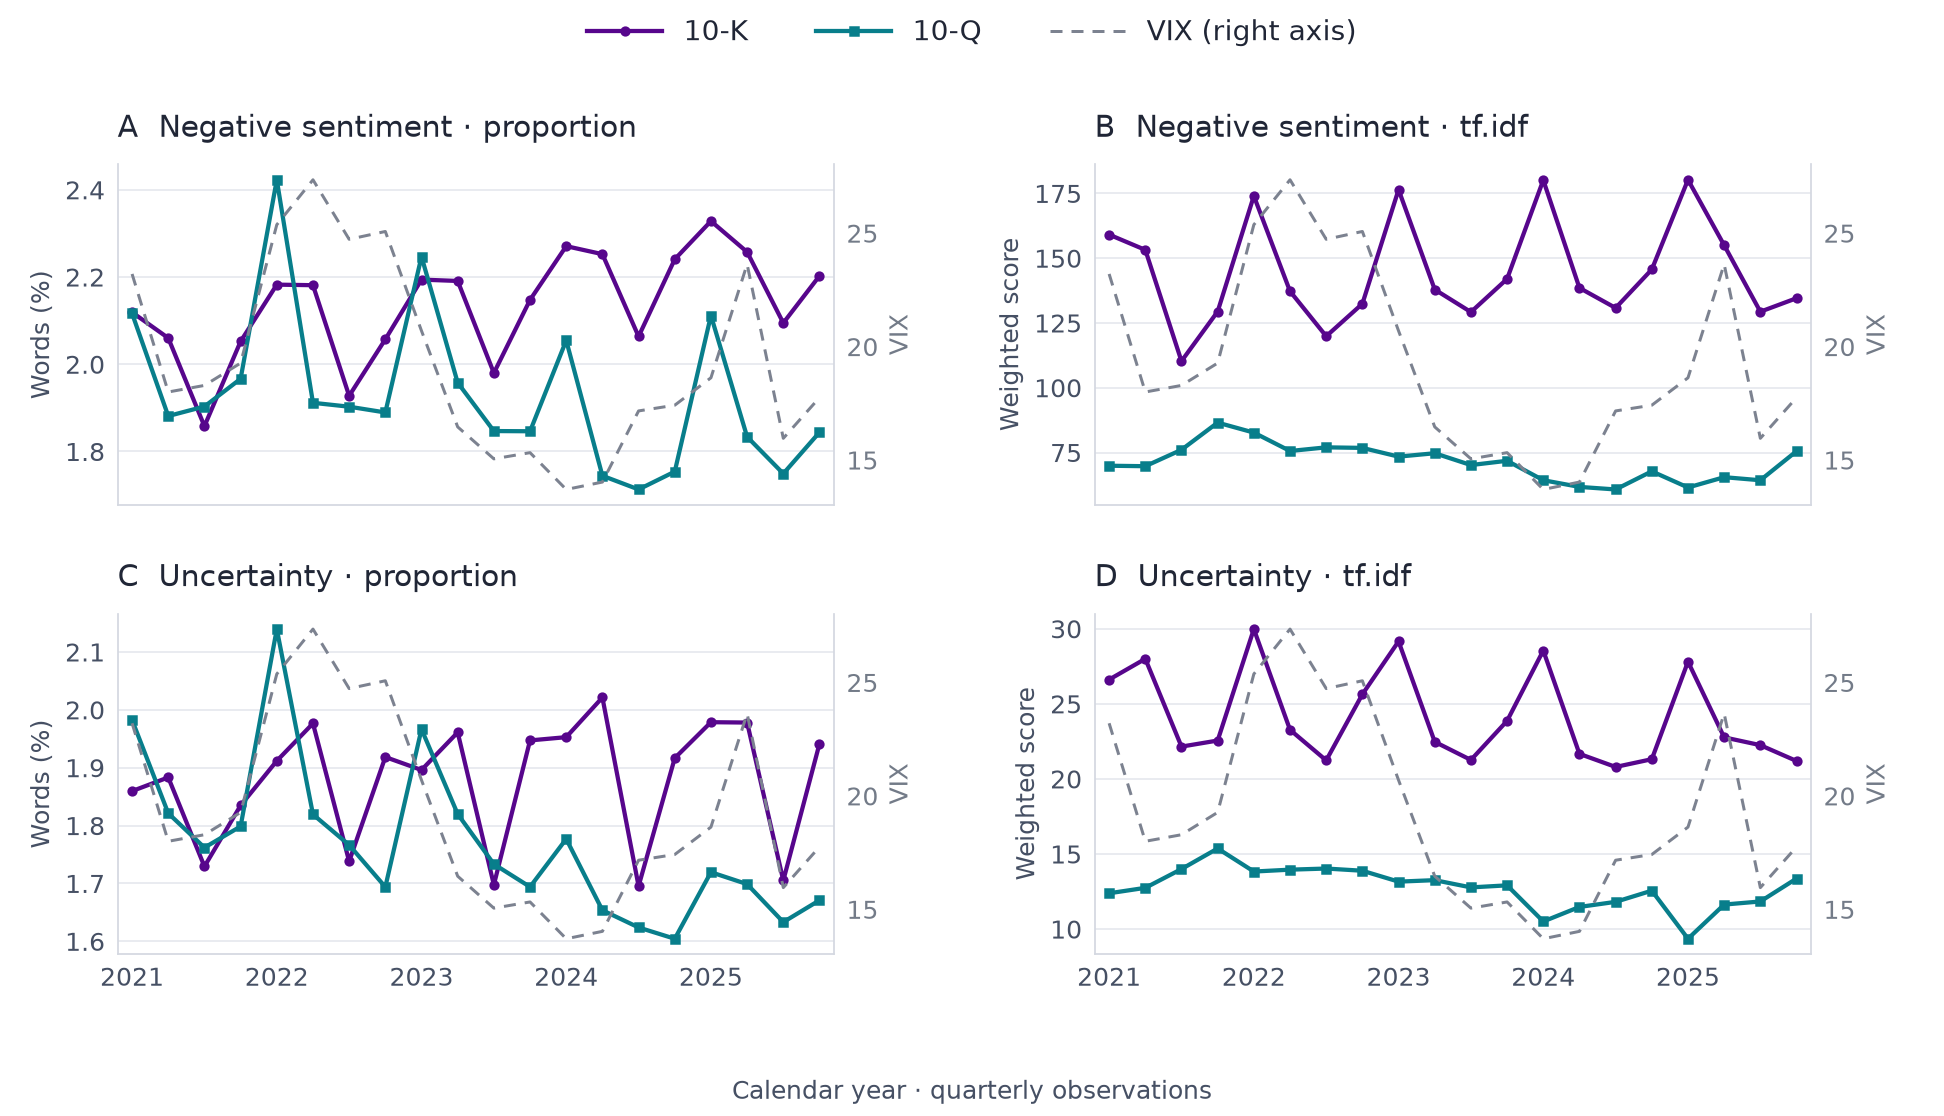

,quarter,form,n_filings,n_firms
0,2021Q1,10-K,43,43
1,2021Q1,10-Q,7,7
2,2021Q2,10-K,1,1
3,2021Q2,10-Q,50,50
4,2021Q3,10-K,1,1
5,2021Q3,10-Q,53,53
6,2021Q4,10-K,5,5
7,2021Q4,10-Q,54,54
8,2022Q1,10-K,53,53
9,2022Q1,10-Q,6,6


In [8]:
if A:
    display(Image(filename=str(ROOT/'outputs/figure1.png')))
    display(A['quarterly'][['quarter','form','n_filings','n_firms']])
else:
    print('Figure pending validated full sample and VIX.')

## Table 4 - Trend tests (Q3)
I interpret the separate-form, within-firm results first because they compare companies with their own earlier language. The form split removes the annual-report mix, while firm and seasonal controls address changes in who files and when. A pooled chart alone cannot make these distinctions.

Quarterly averages weight filings equally and separate 10-K from 10-Q. The trend models control for quarter-of-year seasonality; within-firm models also control for each firm's usual tone, plus form in the pooled model. This addresses both composition problems in the assignment. Firm-clustered errors allow observations from the same company to be related. A separate fixed effect for every calendar quarter would absorb the time trend, so it is not used here. Aggregate models use Newey-West errors because neighboring quarterly averages can be correlated. The main bandwidth is four quarters, with one and two as checks.

Table 4 reports both conventional OLS and robust t-statistics. The main aggregate Newey-West bandwidth is four quarters; one- and two-quarter results are also shown. Within-firm errors cluster by company. Proportional slopes are percentage points per year; weighted slopes are score units per year. A calendar-season control represents quarter 1, 2, 3 or 4 each year, rather than a separate dummy for every dated quarter.

Within firms, annual negative share rises 0.0543 percentage points per year (t=6.21, p<0.001); weighted negativity also rises (3.824 units/year, t=4.68). Quarterly negative share changes by -0.0208 points/year (t=-1.14, p=0.260), which does not establish a trend. Annual uncertainty share rises 0.0220 points/year (t=4.50), while weighted uncertainty declines 0.258 units/year without clear significance (t=-1.66, p=0.102). Quarterly uncertainty falls in both measures: -0.0315 points/year (t=-2.63) and -0.500 weighted units/year (t=-3.14).

These results support changes in disclosure language within firms, with different patterns across forms. They do not establish a uniform rise or fall in underlying economic risk. In particular, annual uncertainty changes direction after weighting down common words. Its rising proportion is consistent with more routine qualifying language, although these counts alone cannot identify why the wording changed. The annual negative trend is clearer because both weights agree. **Investment suggestion:** I would scrutinize holdings with newly rising negative disclosures before increasing their weight. Reducing exposure would also require evidence of weaker operations or financing.

The pooled aggregate weighted-uncertainty p-value is 0.0502, slightly above 5%; rounding it to 0.050 would hide that distinction. I rely on the separate-form within-firm evidence described above rather than that borderline aggregate result.

In [9]:
if A:
    columns = ['form','measure','specification','maxlags','n','n_firms','coefficient','ols_t_stat','t_stat','p_value','ci_low','ci_high','status','reason']
    display(A['table4'].reindex(columns=columns))
else:
    exhibit('table4')

,form,measure,specification,maxlags,n,n_firms,coefficient,ols_t_stat,t_stat,p_value,ci_low,ci_high,status,reason
0,pooled,negative_proportion,aggregate_season_adjusted,4,20,NaN,-0.0152612,-1.34641,-1.65952,0.117768,-0.0348624,0.00433996,estimated,
1,pooled,negative_proportion,aggregate_season_adjusted,1,20,NaN,-0.0152612,-1.34641,-1.22079,0.241007,-0.0419066,0.0113842,estimated,
2,pooled,negative_proportion,aggregate_season_adjusted,2,20,NaN,-0.0152612,-1.34641,-1.38005,0.187794,-0.0388317,0.00830927,estimated,
3,pooled,negative_proportion,within_firm_season_adjusted,NaN,1134,72,-0.00444714,-0.474212,-0.313685,0.75468,-0.0327155,0.0238212,estimated,
4,pooled,negative_tfidf,aggregate_season_adjusted,4,20,NaN,-1.13994,-1.08189,-1.02143,0.323243,-3.5187,1.23881,estimated,
5,pooled,negative_tfidf,aggregate_season_adjusted,1,20,NaN,-1.13994,-1.08189,-0.86809,0.399021,-3.93889,1.659,estimated,
6,pooled,negative_tfidf,aggregate_season_adjusted,2,20,NaN,-1.13994,-1.08189,-0.905854,0.379334,-3.8222,1.54231,estimated,
7,pooled,negative_tfidf,within_firm_season_adjusted,NaN,1134,72,-0.912597,-1.21806,-0.91052,0.365629,-2.91109,1.08589,estimated,
8,pooled,uncertainty_proportion,aggregate_season_adjusted,4,20,NaN,-0.0235493,-2.96725,-3.80878,0.00171221,-0.0367279,-0.0103708,estimated,
9,pooled,uncertainty_proportion,aggregate_season_adjusted,1,20,NaN,-0.0235493,-2.96725,-3.00127,0.00894958,-0.0402736,-0.006825,estimated,


## Table 5 - Subsequent volatility and uncertainty (Q4)
Post-filing volatility is the sample standard deviation of daily returns on [+4,+63], multiplied by $\sqrt{252}$. Pre-filing volatility uses [-60,-6], which contains 55 daily returns. The separate eligibility requirement still needs 60 pre-event and 60 post-event returns. Standard deviations use `ddof=1`.

The market models include firm and calendar-quarter effects, log size (day -1 price times filing-specific shares), log mean dollar volume and prior SPY excess return over [-60,-6], plus a 10-K indicator when pooled. These account for persistent company differences, common quarterly shocks, size, liquidity and recent returns. Table 5 adds pre-filing volatility in its second model; Table 6 always includes it. Errors cluster by firm and quarter to allow both repeated-company dependence and common shocks, using small-sample corrections and t inference. Pre/post volatility is the sample SD of daily returns times sqrt(252), over [-60,-6] (55 returns) and [+4,+63] (60 returns). Four-day excess return is stock buy-and-hold return minus SPY buy-and-hold return over [0,+3], both measured from close -1.

**Q4.** Pooled proportional beta changes from -0.8843 (p=0.604) without pre-filing volatility to -1.0846 (p=0.515) with it, a difference of -0.2003. Both models use the same 1,134 filings, so this change comes from the added control, not a different sample. Pre-filing volatility accounts for a firm's recent risk level: the controlled model asks whether language adds information about future volatility beyond that baseline. The controlled 95% interval, [-4.506, 2.337], includes effects of either sign.

The coefficient does not follow the large-positive-then-smaller pattern discussed in the assignment. Firm effects and the other controls are already included in both columns, removing some persistent differences between risky and stable companies. Adding recent volatility does not reveal a reliable signal here. This is evidence about this specification and sample, not proof that uncertainty language can never matter. Neither coefficient establishes causality. **Investment suggestion:** I would size positions using observed volatility, liquidity and fundamentals. These results do not support changing a risk limit mechanically with the uncertainty-word score.

For annual reports, the proportional coefficient falls from 10.636 to 8.138 when pre-volatility is added; for quarterly reports it falls from 0.648 to 0.343. Neither form shows a clear association under either weight. These differences should not be read as causal effects of filing language.

In [10]:
exhibit('table5')
if A:
    comparisons = A['table5'].pivot(index=['form','regressor'],columns='pre_volatility_control',values=['coefficient','n'])
    display(comparisons)

,form,regressor,specification,maxlags,pre_volatility_control,coefficient,standard_error,ols_t_stat,t_stat,p_value,ci_low,ci_high,n,n_firms,status,reason
0,pooled,uncertainty_proportion,firm_and_quarter_FE,NaN,False,-0.884276,1.67553,-0.590411,-0.527759,0.603776,-4.3912,2.62265,1134,72,estimated,
1,pooled,uncertainty_proportion,firm_and_quarter_FE,NaN,True,-1.08457,1.63479,-0.725527,-0.663432,0.515024,-4.50623,2.33708,1134,72,estimated,
2,pooled,uncertainty_tfidf,firm_and_quarter_FE,NaN,False,-1.30616e-05,0.00111671,-0.0132029,-0.0116965,0.99079,-0.00235037,0.00232425,1134,72,estimated,
3,pooled,uncertainty_tfidf,firm_and_quarter_FE,NaN,True,-9.71536e-05,0.0010881,-0.0984532,-0.0892875,0.929788,-0.00237457,0.00218026,1134,72,estimated,
4,10-K,uncertainty_proportion,firm_and_quarter_FE,NaN,False,10.636,10.0755,0.744153,1.05563,0.304376,-10.4522,31.7242,290,69,estimated,
5,10-K,uncertainty_proportion,firm_and_quarter_FE,NaN,True,8.13818,8.89319,0.589178,0.915103,0.371606,-10.4755,26.7518,290,69,estimated,
6,10-K,uncertainty_tfidf,firm_and_quarter_FE,NaN,False,0.00105474,0.00577543,0.265932,0.182625,0.857027,-0.0110334,0.0131428,290,69,estimated,
7,10-K,uncertainty_tfidf,firm_and_quarter_FE,NaN,True,0.00232534,0.00577462,0.605988,0.402682,0.691677,-0.00976109,0.0144118,290,69,estimated,
8,10-Q,uncertainty_proportion,firm_and_quarter_FE,NaN,False,0.647934,2.97629,0.280235,0.217698,0.829985,-5.58152,6.87739,844,67,estimated,
9,10-Q,uncertainty_proportion,firm_and_quarter_FE,NaN,True,0.343317,3.00102,0.147693,0.1144,0.910121,-5.93789,6.62453,844,67,estimated,


coefficient                  n      
pre_volatility_control               False        True  False True 
form   regressor                                                   
10-K   uncertainty_proportion       10.636      8.13818   290   290
       uncertainty_tfidf        0.00105474   0.00232534   290   290
10-Q   uncertainty_proportion     0.647934     0.343317   844   844
       uncertainty_tfidf       0.000793117   0.00058249   844   844
pooled uncertainty_proportion    -0.884276     -1.08457  1134  1134
       uncertainty_tfidf      -1.30616e-05 -9.71536e-05  1134  1134

## Table 6 - Four-day excess return and negative sentiment
The outcome is the stock's buy-and-hold return over [0,+3] minus SPY's buy-and-hold return over those sessions, both measured from close -1. The model includes firm and calendar-quarter effects, log size, prior log dollar volume, prior excess return, pre-filing volatility and a 10-K indicator. Returns use adjusted prices; dollar amounts use historical nominal prices and volumes.

Before interpreting Table 6, I check how large an effect this design could detect. At a two-sided 5% level and approximately 80% power, the minimum detectable one-SD return effect is (z(0.975) + z(0.80)) times SE(beta) times SD(sentiment) times 100. The normal critical values sum to 2.801585, approximately 1.96 + 0.84. For proportions, 2.801585 x 0.910420 x 0.007876 x 100 gives 2.01 percentage points; for tf.idf, 2.801585 x 0.00016037 x 76.043 x 100 gives 3.42 points. This normal approximation uses the estimated robust errors and may be optimistic with twenty quarter clusters. Smaller return effects can be missed.

Both return coefficients are negative, but their p-values (0.343 and 0.417) do not establish a relationship. Given the detectable-effect calculation, I would not interpret this as evidence of zero economic impact. Other announcements can also occur inside the four-day window. **Investment suggestion:** I would not implement a four-day long-short strategy from these sentiment scores. It would first need a test on later observations that accounts for trading costs and competing announcements.

This calculation describes approximately detectable effects given the estimated standard errors; it is not a measurement of achieved power after seeing the result. The limited return precision is a reason for caution about Table 6, not a reason to dismiss the separate within-firm trend tests.

In [11]:
exhibit('table6')

,regressor,specification,maxlags,coefficient,standard_error,ols_t_stat,t_stat,p_value,ci_low,ci_high,n,n_firms,mde_80pct_one_sd_return_pp,status,reason
0,negative_proportion,firm_and_quarter_FE,NaN,-0.885042,0.91042,-1.09928,-0.972125,0.343203,-2.79057,1.02049,1134,72,2.00894,estimated,
1,negative_tfidf,firm_and_quarter_FE,NaN,-0.000133005,0.000160373,-1.3217,-0.829348,0.417206,-0.000468671,0.00020266,1134,72,3.41661,estimated,


## Annual versus quarterly reports and confidence in the results (Q5, Q6)
**Q5.** Quarterlies average about 25,876 words versus 65,157 for annual reports. Their negative-share variance is 5.77 times the annual variance; uncertainty-share variance is 5.51 times as large. A smaller denominator makes a fixed change in word counts more influential, and differences in sections and firms also matter. More templated language therefore does not necessarily imply less variation in the measured proportion.

Table 4 shows rising annual negative language but no clear quarterly negative-share trend; quarterly uncertainty falls, while the annual result depends on weighting. In Table 5, adding pre-volatility changes the annual proportional coefficient from 10.636 to 8.138 and the quarterly coefficient from 0.648 to 0.343. Neither form gives a reliable volatility association under either weight. I would expect annual reports' fuller business and risk discussions to offer more textual information, but more words also include more standard disclosure. The annual trend is stronger here; superior market prediction is not established. Because 10-Qs can arrive near earnings releases and this dataset has no release timestamps, the filing's own price reaction is not separately identified. **Investment suggestion:** I would use the 10-K for the initial company review and 10-Q changes for follow-up, checking the earnings release before attributing a price move to filing language.

**Q6.** I place the most confidence in the annual negative-language trend: it survives firm and seasonal controls, both weights and the dictionary check. The quarterly uncertainty decline also appears under both weights, but the annual uncertainty disagreement prevents a general claim that firms became more or less uncertain. The volatility tests do not show additional predictive information after the assigned controls; I would not explain that result simply by saying the sample is too small. For returns, the detectable-effect calculation gives a specific reason why a null can coexist with smaller effects. The four tests therefore deserve different conclusions. **Investment suggestion:** I would give the annual negative trend more weight in choosing which holdings to research, while keeping it separate from a demonstrated return signal.

The 2026 holdings select companies still present at the snapshot dates. Of 91 eligible CIKs, 72 enter the final sample and only 55 appear in every year. This does not count firms that ARK sold earlier or firms that failed before the snapshot; their number is unknown here. Even within-firm trends may therefore describe survivors rather than the original investment universe. Missing class-compatible shares add further selection. SPY may not capture these growth firms' sector exposures. Twenty quarters limit aggregate inference, and overlapping return windows create dependence.

Firm fixed effects cannot restore the language histories of firms absent from the holdings snapshot. The direction and size of this selection bias cannot be measured from the snapshot alone. The following dictionary check includes all 2,355 nonzero negative flags while keeping the same filings; uncertainty's list does not change.

In [12]:
if A:
    show_regression(A['starter_sensitivity_table4'].loc[lambda f: f.measure.str.startswith('negative')])
    exhibit('starter_sensitivity_table6')
    print('All required models estimated:', D['failed_regressions'] == 0)
    print('Summary counts reconcile:', D['table2_n_reconciles'])
    print('Input and code fingerprints are saved locally in outputs/diagnostics.json.')


,form,measure,regressor,specification,maxlags,coefficient,standard_error,ols_t_stat,t_stat,p_value,ci_low,ci_high,n,n_firms,status,reason
0,pooled,negative_proportion,time_years,aggregate_season_adjusted,4,-0.0141721,0.00936885,-1.2311,-1.51268,0.151143,-0.0341413,0.00579716,20,NaN,estimated,
1,pooled,negative_proportion,time_years,aggregate_season_adjusted,1,-0.0141721,0.0127376,-1.2311,-1.11261,0.283388,-0.0413217,0.0129776,20,NaN,estimated,
2,pooled,negative_proportion,time_years,aggregate_season_adjusted,2,-0.0141721,0.0112892,-1.2311,-1.25537,0.22855,-0.0382344,0.00989022,20,NaN,estimated,
3,pooled,negative_proportion,time_years,within_firm_season_adjusted,NaN,-0.00446059,0.0141813,-0.476221,-0.314539,0.754034,-0.0327374,0.0238162,1134,72,estimated,
4,pooled,negative_tfidf,time_years,aggregate_season_adjusted,4,-1.14214,1.12594,-1.07519,-1.01439,0.32648,-3.54202,1.25774,20,NaN,estimated,
5,pooled,negative_tfidf,time_years,aggregate_season_adjusted,1,-1.14214,1.32485,-1.07519,-0.86209,0.402211,-3.96599,1.68171,20,NaN,estimated,
6,pooled,negative_tfidf,time_years,aggregate_season_adjusted,2,-1.14214,1.26959,-1.07519,-0.899612,0.382542,-3.84821,1.56393,20,NaN,estimated,
7,pooled,negative_tfidf,time_years,within_firm_season_adjusted,NaN,-0.9328,1.00661,-1.23655,-0.926673,0.357235,-2.93993,1.07433,1134,72,estimated,
16,10-K,negative_proportion,time_years,aggregate_season_adjusted,4,0.0517329,0.00356224,11.0193,14.5226,3.06208e-10,0.0441402,0.0593256,20,NaN,estimated,
17,10-K,negative_proportion,time_years,aggregate_season_adjusted,1,0.0517329,0.0043662,11.0193,11.8485,5.14159e-09,0.0424265,0.0610392,20,NaN,estimated,


,regressor,specification,maxlags,coefficient,standard_error,ols_t_stat,t_stat,p_value,ci_low,ci_high,n,n_firms,mde_80pct_one_sd_return_pp,status,reason
0,negative_proportion,firm_and_quarter_FE,NaN,-0.898851,0.906434,-1.11429,-0.991634,0.333838,-2.79604,0.998338,1134,72,1.98733,estimated,
1,negative_tfidf,firm_and_quarter_FE,NaN,-0.000134301,0.000159964,-1.3437,-0.839571,0.411589,-0.000469108,0.000200507,1134,72,3.42909,estimated,


All required models estimated: True
Summary counts reconcile: True
Input and code fingerprints are saved locally in outputs/diagnostics.json.


## Sensitivity to extreme market observations
The primary analysis keeps large observed returns. A check caps four market variables at their 1st and 99th percentiles, changing 24 observations per variable while preserving all firms and tone scores. Controlled pooled volatility beta becomes -0.7251 (p=0.606); return p-values are 0.281, 0.345. The null conclusions remain. This check was motivated partly by LUNR's pre-filing window: both adjusted and nominal histories show a 251.4% rise on 16 February 2023 and a 75.2% fall on 23 February. Large moves alone do not justify deleting valid observations. **Investment suggestion:** I would stress-test exposure to extreme moves before setting position sizes; the capped results still do not justify trading the language scores.

The notebook reports every specification tried: pooled and separate-form models, both weights, aggregate NW lags 4/1/2, both pre-volatility variants, both sentiment return models, the starter-list check and a 1%/99% market-variable cap. With all 2,355 negative words, the annual within-firm negative-share slope is 0.0536 (t=6.33); return p-values are 0.334, 0.412. The main conclusions remain the same. **Investment suggestion:** The dictionary check gives me no reason to change the research priorities or adopt a sentiment trading rule.

In [13]:
if A:
    from src.robustness import market_winsor_sensitivity
    sensitivity = market_winsor_sensitivity(A['panel'])
    for name, frame in sensitivity.items():
        frame.to_csv(ROOT/'outputs'/f'{name}.csv', index=False)
        display(Markdown('**'+name.replace('_',' ')+'**'))
        if 'coefficient' in frame:
            show_regression(frame)
        else:
            display(frame)

**winsorized table5**

,form,regressor,specification,maxlags,pre_volatility_control,coefficient,standard_error,ols_t_stat,t_stat,p_value,ci_low,ci_high,n,n_firms,status,reason
0,pooled,uncertainty_proportion,firm_and_quarter_FE,NaN,False,-0.391313,1.4485,-0.278516,-0.27015,0.789957,-3.42306,2.64044,1134,72,estimated,
1,pooled,uncertainty_proportion,firm_and_quarter_FE,NaN,True,-0.725061,1.38328,-0.519773,-0.524161,0.606228,-3.6203,2.17018,1134,72,estimated,
2,pooled,uncertainty_tfidf,firm_and_quarter_FE,NaN,False,0.000355394,0.00102388,0.383078,0.347107,0.732326,-0.0017876,0.00249839,1134,72,estimated,
3,pooled,uncertainty_tfidf,firm_and_quarter_FE,NaN,True,0.000168283,0.000973567,0.182743,0.172852,0.864596,-0.00186942,0.00220598,1134,72,estimated,
4,10-K,uncertainty_proportion,firm_and_quarter_FE,NaN,False,10.5205,9.59119,0.75416,1.09689,0.286397,-9.55408,30.5951,290,69,estimated,
5,10-K,uncertainty_proportion,firm_and_quarter_FE,NaN,True,8.82854,8.63533,0.656737,1.02237,0.319446,-9.24541,26.9025,290,69,estimated,
6,10-K,uncertainty_tfidf,firm_and_quarter_FE,NaN,False,0.00088338,0.00569417,0.227944,0.155138,0.878349,-0.0110347,0.0128014,290,69,estimated,
7,10-K,uncertainty_tfidf,firm_and_quarter_FE,NaN,True,0.00232966,0.00563033,0.6221,0.41377,0.683676,-0.00945476,0.0141141,290,69,estimated,
8,10-Q,uncertainty_proportion,firm_and_quarter_FE,NaN,False,1.4577,2.54405,0.677271,0.572985,0.573374,-3.86706,6.78246,844,67,estimated,
9,10-Q,uncertainty_proportion,firm_and_quarter_FE,NaN,True,0.655418,2.61909,0.303576,0.250247,0.805082,-4.82639,6.13723,844,67,estimated,


**winsorized table6**

,regressor,specification,maxlags,coefficient,standard_error,ols_t_stat,t_stat,p_value,ci_low,ci_high,n,n_firms,mde_80pct_one_sd_return_pp,status,reason
0,negative_proportion,firm_and_quarter_FE,NaN,-0.83843,0.755574,-1.14636,-1.10966,0.280993,-2.41986,0.743004,1134,72,1.66725,estimated,
1,negative_tfidf,firm_and_quarter_FE,NaN,-0.000134515,0.000139035,-1.47237,-0.967491,0.345454,-0.000425518,0.000156488,1134,72,2.962,estimated,


**winsorization bounds**

,variable,lower,upper,changed
0,pre_volatility,0.138156,1.36303,24
1,post_volatility,0.143103,1.30242,24
2,prior_excess_return,-0.464846,1.00122,24
3,event_return,-0.26094,0.370557,24


## Appendix A. Company status and sample eligibility
This appendix identifies all 130 holding identities in the supplied snapshot and shows which companies pass the data filters. Public status is established from the cached SEC ticker/exchange records or the reviewed company, exchange and fund sources linked in the notebook. It describes the available 2026 listing evidence, not a claim that every company was public throughout 2021-2025. A public company can have no qualifying filing in the historical window. No company is called private merely because it has no 10-K/Q. Listed funds are identified separately.

In Table A1, **Text = Yes** means the issuer has at least one filing after the first three text filters. **Market = Yes** means at least one filing passes every filter for Tables 1-6; it does not mean all its filings pass. Funds abbreviate ARKK/Q/W/F/G/X as K/Q/W/F/G/X. The snapshot dates remain 4 September 2026 for K/Q/W/G and 2 January 2026 for F/X. SEC CIKs distinguish issuers from holding tickers: Alphabet's two share tickers appear in the identity list but share one issuer history, counted once in Table A2. Blank CIKs mean no US issuer mapping was used, not that the holding is private.



Cand. includes amendments; Orig. follows amendment/parse filtering. Text follows the word minimum and earliest-company-quarter rule; no original filing fails the word minimum. Price adds usable day 0 and the $3 screen; Hist. adds 60 returns before and after; Win. adds complete prescribed windows; Shares adds filing-specific shares. Final K and Final Q also pass all controls. Their totals are 290 and 844, so 72 of 91 issuers contribute 1,134 final filings. The Text column sums to 1,655. Level and Trend availability refer to the separate Item 1A-excluded rankings defined next, so they can remain available when market filters fail.



**Investment suggestion:** Missing coverage is a reason for further disclosure review, not a low-risk classification or a reason to increase a position.

In [14]:
from IPython.display import HTML
from src.rankings import run_rankings
from src.company_appendix import build_company_appendix
risk_panel, holdings_ranks, ranking_top, ranking_summary = run_rankings(ROOT)
holding_identities, company_filters, company_summary = build_company_appendix(ROOT, risk_panel, holdings_ranks)
display(Markdown('**Appendix A1 - Every holding identity, listing evidence and eligibility**'))
identity_columns = ['raw_ticker','ark_name','cusip','ticker','cik','public_status','listing','funds',
    'snapshot_dates','text_eligible','market_eligible','status','reason','listing_source','listing_evidence_date']
display(HTML(holding_identities[identity_columns].to_html(index=False, render_links=True)))
display(Markdown('**Appendix A2 - Filing counts after each filter, one row per SEC issuer**'))
filter_columns = ['ticker','sec_name','cik','ticker_aliases','Industry','Candidates','Original','Word minimum',
    'Text','Price','History','Windows','Shares','Final','Final K','Final Q','Ex Item1A',
    'First filing','Last filing','Market eligible','K level','Q level','K trend','Q trend']
display(HTML(company_filters[filter_columns].to_html(index=False)))
display(Markdown('**Reconciliation**'))
display(pd.DataFrame([company_summary['filter_totals']]))
print('Holding identities:', company_summary['holding_identities'],
      '| SEC issuers with eligible filings:', company_summary['eligible_issuers'],
      '| SEC issuers passing market filters:', company_summary['market_eligible_issuers'])


**Appendix A1 - Every holding identity, listing evidence and eligibility**

raw_ticker,ark_name,cusip,ticker,cik,public_status,listing,funds,snapshot_dates,text_eligible,market_eligible,status,reason,listing_source,listing_evidence_date
2618,JD LOGISTICS INC,BNMBPD9,,,Public company,Hong Kong,ARKX,01/02/2026,No,No,excluded_numeric_listing,Numeric foreign-exchange listing under starter eligibility rule,https://www1.hkexnews.hk/listedco/listconews/sehk/2025/1009/2025100900073.pdf,2026-09-12 (source review)
4689,LY CORP,6084848,,,Public company,Tokyo,ARKF,01/02/2026,No,No,excluded_numeric_listing,Numeric foreign-exchange listing under starter eligibility rule,https://www.lycorp.co.jp/en/ir/faq.html,2026-09-12 (source review)
6301,KOMATSU LTD,6496584,,,Public company,Tokyo,ARKX,01/02/2026,No,No,excluded_numeric_listing,Numeric foreign-exchange listing under starter eligibility rule,https://www.komatsu.jp/en/ir/faq,2026-09-12 (source review)
ABNB,AIRBNB INC-CLASS A,009066101,ABNB,0001559720,Public company,Nasdaq,ARKF|ARKW,01/02/2026|09/04/2026,Yes,No,domestic_filer,10-K/Q filings present in the assignment window,https://data.sec.gov/submissions/CIK0001559720.json,2026-09-08T20:43:55.043434+00:00
ABSI,ABSCI CORP,00091E109,ABSI,0001672688,Public company,Nasdaq,ARKG,09/04/2026,Yes,Yes,domestic_filer,10-K/Q filings present in the assignment window,https://data.sec.gov/submissions/CIK0001672688.json,2026-09-08T20:43:55.652214+00:00
ACHR,ARCHER AVIATION INC-A,03945R102,ACHR,0001824502,Public company,NYSE,ARKK|ARKQ|ARKX,01/02/2026|09/04/2026,Yes,Yes,domestic_filer,10-K/Q filings present in the assignment window,https://data.sec.gov/submissions/CIK0001824502.json,2026-09-08T20:43:55.864144+00:00
ADPT,ADAPTIVE BIOTECHNOLOGIES,00650F109,ADPT,0001478320,Public company,Nasdaq,ARKG,09/04/2026,Yes,Yes,domestic_filer,10-K/Q filings present in the assignment window,https://data.sec.gov/submissions/CIK0001478320.json,2026-09-08T20:43:56.090830+00:00
ADYEN,ADYEN NV,BZ1HM42,ADYEN,,Public company,Foreign listing,ARKF,01/02/2026,No,No,reviewed_foreign_listing,Adyen ordinary shares listed on Euronext Amsterdam; no eligible US ticker verified for this holding,https://www.adyen.com/press-and-media/adyen-hosts-investor-day-2025-in-amsterdam,2026 snapshot / reviewed source
AIR,AIRBUS SE,4012250,AIR,,Public company,Foreign listing,ARKX,01/02/2026,No,No,reviewed_foreign_listing,"Airbus European AIR listing; SEC ticker AIR identifies AAR Corp, a different issuer; no eligible US ticker verified",https://www.airbus.com/en/investors/share-price-and-information,2026 snapshot / reviewed source
ALMR,ALAMAR BIOSCIENCES INC,010911105,ALMR,0002104204,Public company,Nasdaq,ARKG,09/04/2026,No,No,no_10x_filings,No 10-K or 10-Q in cached SEC submissions for assignment filing-date window,https://data.sec.gov/submissions/CIK0002104204.json,2026-09-08T20:43:56.925978+00:00


**Appendix A2 - Filing counts after each filter, one row per SEC issuer**

ticker,sec_name,cik,ticker_aliases,Industry,Candidates,Original,Word minimum,Text,Price,History,Windows,Shares,Final,Final K,Final Q,Ex Item1A,First filing,Last filing,Market eligible,K level,Q level,K trend,Q trend
ABNB,"Airbnb, Inc.",0001559720,ABNB,Services-To Dwellings & Other Buildings,20,20,20,20,20,19,19,0,0,0,0,20,2021-02-26,2025-11-06,No,Yes,Yes,Yes,Yes
ABSI,Absci Corp,0001672688,ABSI,Services-Commercial Physical & Biological Research,19,18,18,18,12,11,11,11,11,3,8,18,2021-09-07,2025-11-12,Yes,Yes,Yes,Yes,Yes
ACHR,Archer Aviation Inc.,0001824502,ACHR,Aircraft,22,20,20,20,16,15,15,5,5,1,4,20,2021-03-08,2025-11-06,Yes,Yes,Yes,Yes,Yes
ADPT,Adaptive Biotechnologies Corp,0001478320,ADPT,"Biological Products, (No Diagnostic Substances)",20,20,20,20,20,20,20,20,20,5,15,20,2021-02-24,2025-11-05,Yes,Yes,Yes,Yes,Yes
AMD,ADVANCED MICRO DEVICES INC,0000002488,AMD,Semiconductors & Related Devices,20,20,20,20,20,20,20,20,20,5,15,20,2021-01-29,2025-11-05,Yes,Yes,Yes,Yes,Yes
AMZN,AMAZON COM INC,0001018724,AMZN,Retail-Catalog & Mail-Order Houses,20,20,20,20,20,20,20,20,20,5,15,20,2021-02-03,2025-10-31,Yes,Yes,Yes,Yes,Yes
ARCT,Arcturus Therapeutics Holdings Inc.,0001768224,ARCT,Pharmaceutical Preparations,20,20,20,20,20,20,20,20,20,5,15,20,2021-03-01,2025-11-12,Yes,Yes,Yes,Yes,Yes
AUR,"Aurora Innovation, Inc.",0001828108,AUR,Services-Computer Integrated Systems Design,21,19,19,19,15,14,14,12,12,3,9,19,2021-05-17,2025-10-28,Yes,Yes,Yes,Yes,Yes
AVAV,AeroVironment Inc,0001368622,AVAV,Aircraft,21,20,20,20,20,20,20,20,20,5,15,20,2021-03-10,2025-12-10,Yes,Yes,Yes,Yes,Yes
AVGO,Broadcom Inc.,0001730168,AVGO,Semiconductors & Related Devices,20,20,20,20,20,20,20,20,20,5,15,20,2021-03-12,2025-12-18,Yes,Yes,Yes,Yes,Yes


**Reconciliation**

,Candidates,Original,Word minimum,Text,Price,History,Windows,Shares,Final
0,1709,1663,1663,1655,1547,1524,1524,1134,1134


Holding identities: 130 | SEC issuers with eligible filings: 91 | SEC issuers passing market filters: 72


## Holdings uncertainty outside Item 1A and investment decisions
The additional screen ranks the holdings by uncertainty outside Item 1A. I interpret the requested low end as **lowest uncertainty**, the opposite of highest uncertainty. These are rankings of language in 2021-2025 filings of the assigned holdings snapshot, not estimates of current stock value or probabilities of loss.

I remove the body of Item 1A, Risk Factors, in each form, then recount uncertainty words and all remaining words using the same parser and active March 2026 dictionary. The score is 100 times uncertainty-word occurrences outside Item 1A divided by all parsed words outside Item 1A. Removing only uncertainty words while keeping the original denominator would give the wrong percentage. Contents links and references to Item 1A elsewhere are not treated as the section itself; risk discussion elsewhere remains part of the score. Omitted sections are distinguished from unresolved boundaries, which are excluded rather than given a zero score. The [SEC's guide to filing sections](https://www.investor.gov/introduction-investing/general-resources/news-alerts/alerts-bulletins/investor-bulletins/how-read) identifies Item 1A as the risk-factor discussion. Excluding it for this requested measure does not mean ignoring it when evaluating an investment.

This separate text screen starts with 1,655 filings from 91 companies after the amendment, word-count and earliest-company-quarter filters. It does not require prices or shares. The original Tables 1-6 continue to use their common 1,134-filing sample; this extension uses proportions and needs no new IDF fit. Section audit: 10-K / found: 406; 10-Q / absent: 15; 10-Q / found: 1,234. There are 0 unresolved filings after 2 source-verified boundary reviews. These are MercadoLibre's 2021 and 2022 annual filings, where a direction mark precedes the heading. Their unique body openings and following Item 1B headings were checked, and the code verifies the exact source hashes before applying the reviewed ranges. The notebook saves the coverage, removal counts and source links.

Levels are equal-weight means of filings submitted in 2025, with annual and quarterly forms ranked separately. This is filing year, so a 2025 annual filing may cover fiscal 2024. Annual reports are the main comparison; quarterly results also cover newer filers. A 10-K level needs one final-year filing and a 10-Q level needs two. Annual levels cover 88 companies; quarterly levels cover 91. Companies without an annual level are CRCL, CRWV, FIG; a missing level is not low uncertainty.

Annual changes are OLS slopes of each company's annual-report percentage on filing year, after averaging multiple 10-Ks within a year. Quarterly slopes use filing observations and quarter-of-year controls. Both need at least three observed years, including 2025; quarterly slopes also need eight filings and three residual degrees of freedom. This gives 83 annual and 84 quarterly slopes. A change of +0.10 means an increase of 0.10 percentage points per year. Histories differ, so the table shows their span and number of filings. These are descriptive rankings of fitted changes, with only three to five annual observations; selecting the extremes does not make them statistically established trends.


In [15]:
from IPython.display import HTML
from src.rankings import run_rankings
display(Markdown("**Extraction and ranking coverage**"))
display(risk_panel.groupby(['form', 'status']).agg(
    Filings=('accession', 'size'), Original_words=('original_n_words', 'sum'),
    Removed_words=('removed_n_words', 'sum'), Retained_words=('retained_n_words', 'sum')))
display(Markdown('**Reviewed section boundaries**'))
display(risk_panel[risk_panel.boundary_review.ne('')][['ticker','form','filing_date','accession',
    'start_heading','end_heading','removed_n_words','retained_n_words','boundary_review','doc_url']])
display(Markdown("**Table 7 - Highest, lowest, largest rise and largest fall**"))
display(ranking_top)
for form in ['10-K', '10-Q']:
    display(Markdown('**Complete ' + form + ' holdings ranking**'))
    group = holdings_ranks[holdings_ranks.form.eq(form)].copy()
    group['Years'] = group.apply(lambda r: str(int(r.first_year))+'–'+str(int(r.last_year))
                                if pd.notna(r.first_year) else 'none', axis=1)
    columns = ['ticker', 'rank_highest', 'rank_lowest', 'uncertainty_pct', 'n_latest',
               'slope_pp_year', 'rank_rise', 'rank_fall', 'Years', 'n_filings']
    view = group[columns].rename(columns={'ticker':'Holding','rank_highest':'High rank',
        'rank_lowest':'Low rank','uncertainty_pct':'2025 uncertainty (%)','n_latest':'2025 N',
        'slope_pp_year':'Change (pp/year)','rank_rise':'Rise rank','rank_fall':'Fall rank',
        'n_filings':'History N'})
    integer = ['High rank','Low rank','2025 N','Rise rank','Fall rank','History N']
    formatters = {c:lambda x: str(int(x)) for c in integer}
    formatters.update({'2025 uncertainty (%)':lambda x:f'{x:.3f}',
                       'Change (pp/year)':lambda x:f'{x:+.4f}'})
    display(HTML(view.to_html(index=False, na_rep='—', formatters=formatters)))
display(Markdown('**Unranked cases and reasons**'))
display(holdings_ranks[holdings_ranks.level_status.ne('ranked') |
                      holdings_ranks.trend_status.ne('ranked')][
    ['ticker','form','n_latest','n_years','n_filings','n_unresolved','level_status','trend_status']])
display(Markdown('**2025 source filings for the displayed leaders**'))
leader_tickers = set(ranking_top.ticker)
sources = risk_panel[risk_panel.ticker.isin(leader_tickers) &
                     pd.to_datetime(risk_panel.filing_date).dt.year.eq(2025)][
    ['ticker','form','filing_date','uncertainty_pct','original_uncertainty_pct',
     'removed_n_words','retained_n_words','status','doc_url']]
display(HTML(sources.to_html(index=False, render_links=True, na_rep='—', float_format=lambda x:f'{x:.4f}')))
unresolved = risk_panel[risk_panel.status.eq('ambiguous')]
if len(unresolved):
    display(Markdown('**Unresolved section boundaries: excluded from ranking**'))
    display(unresolved[['ticker','form','filing_date','accession','status']])


**Extraction and ranking coverage**

Filings  Original_words  Removed_words  Retained_words
form status                                                        
10-K found       406        26636338    9.62198e+06     1.70144e+07
10-Q absent       15          141953              0          141953
     found      1234        35834574    1.51702e+07     2.06644e+07

**Reviewed section boundaries**

,ticker,form,filing_date,accession,start_heading,end_heading,removed_n_words,retained_n_words,boundary_review,doc_url
49,MELI,10-K,2021-03-01,0001562762-21-000079,ITEM 1A. RISK FACTORS,ITEM 1B. UNRESOLVED STAFF COMMENTS,13288,47968,Source-verified MELI annual-report boundaries,https://www.sec.gov/Archives/edgar/data/1099590/000156276221000079/meli-20201231x10k.htm
330,MELI,10-K,2022-02-23,0001562762-22-000049,ITEM 1A. RISK FACTORS,ITEM 1B. UNRESOLVED STAFF COMMENTS,13681,50339,Source-verified MELI annual-report boundaries,https://www.sec.gov/Archives/edgar/data/1099590/000156276222000049/meli-20211231x10k.htm


**Table 7 - Highest, lowest, largest rise and largest fall**

...

Holding,High rank,Low rank,2025 uncertainty (%),2025 N,Change (pp/year),Rise rank,Fall rank,Years,History N
AVGO,1,91,1.777,3,+0.0282,30,—,2021–2025,15
LLY,2,90,1.765,3,+0.0725,11,—,2021–2025,15
DKNG,3,89,1.736,3,+0.0046,41,—,2022–2025,12
LMT,4,88,1.674,3,+0.0074,38,—,2021–2025,15
MASS,5,87,1.667,3,+0.0908,6,—,2021–2025,15
NET,6,86,1.624,3,+0.0331,24,—,2021–2025,15
VCYT,7,85,1.609,3,+0.0287,29,—,2021–2025,15
PACB,8,84,1.601,3,+0.1144,2,—,2021–2025,15
SHOP,9,83,1.580,3,—,—,—,2025–2025,3
ABSI,10,82,1.578,3,+0.0809,7,—,2021–2025,14


**Unranked cases and reasons**

,ticker,form,n_latest,n_years,n_filings,n_unresolved,level_status,trend_status
33,SHOP,10-K,1,1,1,0,ranked,fewer than three years or missing final year
43,TEM,10-K,1,1,1,0,ranked,fewer than three years or missing final year
57,FRNM,10-K,1,1,1,0,ranked,fewer than three years or missing final year
58,RBRK,10-K,1,1,1,0,ranked,fewer than three years or missing final year
59,KDK,10-K,1,2,2,0,ranked,fewer than three years or missing final year
88,CRCL,10-K,0,0,0,0,insufficient final-year filings,fewer than three years or missing final year
89,CRWV,10-K,0,0,0,0,insufficient final-year filings,fewer than three years or missing final year
90,FIG,10-K,0,0,0,0,insufficient final-year filings,fewer than three years or missing final year
99,SHOP,10-Q,3,1,3,0,ranked,fewer than three years or missing final year
125,FIG,10-Q,2,1,2,0,ranked,fewer than three years or missing final year


**2025 source filings for the displayed leaders**

ticker,form,filing_date,uncertainty_pct,original_uncertainty_pct,removed_n_words,retained_n_words,status,doc_url
BMNR,10-Q,2025-01-10,0.9251,0.9296,29.0000,16107.0000,found,https://www.sec.gov/Archives/edgar/data/1829311/000168316825000223/bitmine_i10q-113024.htm
META,10-K,2025-01-30,1.5098,1.8677,28636.0000,41397.0000,found,https://www.sec.gov/Archives/edgar/data/1326801/000132680125000017/meta-20241231.htm
TSLA,10-K,2025-01-30,1.0110,1.5795,12051.0000,37586.0000,found,https://www.sec.gov/Archives/edgar/data/1318605/000162828025003063/tsla-20241231.htm
TWST,10-Q,2025-02-03,1.0110,1.1191,133.0000,8803.0000,found,https://www.sec.gov/Archives/edgar/data/1581280/000162828025003461/twst-20241231.htm
Z,10-K,2025-02-11,1.4004,2.1147,22212.0000,41059.0000,found,https://www.sec.gov/Archives/edgar/data/1617640/000161764025000016/z-20241231.htm
ILMN,10-K,2025-02-12,1.6887,2.0956,10615.0000,38727.0000,found,https://www.sec.gov/Archives/edgar/data/1110803/000111080325000019/ilmn-20241229.htm
IRDM,10-K,2025-02-13,0.9715,1.5165,12425.0000,40658.0000,found,https://www.sec.gov/Archives/edgar/data/1418819/000162828025005302/irdm-20241231.htm
DKNG,10-K,2025-02-14,1.6509,2.3453,27090.0000,45309.0000,found,https://www.sec.gov/Archives/edgar/data/1883685/000188368525000010/dkng-20241231.htm
HON,10-K,2025-02-14,1.0251,1.5400,12539.0000,38044.0000,found,https://www.sec.gov/Archives/edgar/data/773840/000077384025000010/hon-20241231.htm
DASH,10-K,2025-02-14,1.4287,2.2639,32847.0000,32968.0000,found,https://www.sec.gov/Archives/edgar/data/1792789/000162828025005715/dash-20241231.htm


### Investment suggestions from the holdings rankings

**Highest uncertainty - LLY (1.746%).** I would defer increasing exposure to LLY until reviewing the uncertain statements in its operating and financial discussion and checking whether cash generation and financing capacity support the investment case. A high word share justifies this review; it does not establish that the stock will fall.

**Lowest uncertainty - IONS (0.823%).** I would consider IONS for further investment research, then check whether the low score reflects clear, stable disclosures or simply less discussion of uncertain outcomes. I would add to a position only if valuation and financial performance also support it; a low language score alone does not justify a larger weight.

**Largest annual rise - WGS (+0.1316 pp/year).** I would review WGS's changed passages before committing new capital. If the increase corresponds to deteriorating operations or funding pressure, I would reduce the proposed position size. If it comes mainly from accounting explanations or qualifications, I would keep the allocation decision tied to the underlying numbers.

**Largest annual fall - META (-0.0666 pp/year).** I would place META on an improving-disclosure watchlist. Before adding exposure, I would require evidence that the uncertainty has resolved, rather than that management shortened or moved the discussion. A declining score is a reason to investigate a possible improvement, not proof of a recovery.

**Quarterly decisions.** AVGO has the highest quarterly level (1.777%); I would review its disclosures before adding exposure. INTU has the lowest (0.781%); I would research its fundamentals and valuation before treating this as an allocation opportunity. For the largest rise, WGS (+0.1362 pp/year), I would investigate what changed before committing more capital. For the largest fall, LHX (-0.1224 pp/year), I would require evidence of business improvement before adding to a position. Agreement across forms gives a more consistent disclosure history, but it is still not independent validation of a return forecast. Disagreement calls for reading the changed sections and checking timing, not averaging the scores into a buy or sell signal.

**Comparison across forms.** LLY is among the three highest and IONS among the three lowest under both forms. WGS has the largest increase in both annual and quarterly reports, with PACB also in both rising groups. I would prioritize those repeated patterns for review because the ordering is less dependent on the choice of filing form. This agreement still comes from the same companies' disclosures and does not validate a return forecast.

**Portfolio takeaway.** I would use these rankings to decide where to spend research time and which proposed position sizes need another review. Industry differences, changes around mergers or listings, and disclosure structure can affect the ordering even after Item 1A is removed. I would base any actual reallocation on the identified passages, company finances and valuation. The weak volatility and return evidence in Tables 5-6 does not support a mechanical long-low-uncertainty, short-high-uncertainty portfolio. A chronological test, including costs, would be needed before using such a rule with capital.


## What I would do next and reproducibility
The most useful improvement would be a historical holdings panel, including exited and failed firms, with matching issuer and share-class histories. It would require more data collection and manual mapping, but would directly address the main selection and share-count problems. A later forecasting exercise should fit IDF only on earlier filings and evaluate later periods separately. **Investment suggestion:** I would require that historical-universe test, with realistic trading costs, before committing capital to a strategy based on these findings.

The notebook saves all required tables, the figure and the stated sensitivity checks. [README.md](README.md) gives the download and execution commands; [AI_USE.md](AI_USE.md) explains the assistance used. Downloaded observations, caches, complete regression artifacts and checksums stay in ignored `data/` and `outputs/` directories. No data files are included in the GitHub submission. The PDF report is the separate Brightspace deliverable.